# Notebook 1: CIC IDS 2017 — Data Preparation & Exploratory Analysis

**Research Context:**  
This notebook handles acquisition, cleaning, and EDA of the CIC IDS 2017 dataset.  
The processed artefacts are used by Notebooks 2 (ML Baselines) and 3 (DQN Agent).

**Dataset:** Canadian Institute for Cybersecurity — Intrusion Detection System 2017  
**URL:** https://www.unb.ca/cic/datasets/ids-2017.html  
**Features:** 78 network flow features + 1 label column  
**Attack types:** DoS, DDoS, PortScan, Brute Force, Web Attacks, Infiltration, Botnet

---

## 0. Install Dependencies

In [12]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn tqdm joblib -q

## 1. Imports

In [13]:
import os, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = Path('processed')
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

print('Imports OK')

Imports OK


## 2. Dataset Download Helper

The CIC IDS 2017 CSVs (~450 MB uncompressed) must be placed in `./data/`.  
The cell below checks for local files and, if missing, downloads a representative  
synthetic surrogate so all downstream cells still execute correctly.

**To use the real dataset:**
1. Download from: https://www.unb.ca/cic/datasets/ids-2017.html
2. Place all `*_TrafficFlowMeter.csv` files in `./data/`
3. Re-run from this cell.

In [14]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# ---- real CIC IDS 2017 column names (78 features) ----
CIC_COLUMNS = [
    'Destination Port','Flow Duration','Total Fwd Packets','Total Backward Packets',
    'Total Length of Fwd Packets','Total Length of Bwd Packets',
    'Fwd Packet Length Max','Fwd Packet Length Min','Fwd Packet Length Mean','Fwd Packet Length Std',
    'Bwd Packet Length Max','Bwd Packet Length Min','Bwd Packet Length Mean','Bwd Packet Length Std',
    'Flow Bytes/s','Flow Packets/s',
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Total','Fwd IAT Mean','Fwd IAT Std','Fwd IAT Max','Fwd IAT Min',
    'Bwd IAT Total','Bwd IAT Mean','Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Fwd PSH Flags','Bwd PSH Flags','Fwd URG Flags','Bwd URG Flags',
    'Fwd Header Length','Bwd Header Length',
    'Fwd Packets/s','Bwd Packets/s',
    'Min Packet Length','Max Packet Length','Packet Length Mean','Packet Length Std','Packet Length Variance',
    'FIN Flag Count','SYN Flag Count','RST Flag Count','PSH Flag Count',
    'ACK Flag Count','URG Flag Count','CWE Flag Count','ECE Flag Count',
    'Down/Up Ratio','Average Packet Size','Avg Fwd Segment Size','Avg Bwd Segment Size',
    'Fwd Header Length.1',
    'Fwd Avg Bytes/Bulk','Fwd Avg Packets/Bulk','Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk','Bwd Avg Packets/Bulk','Bwd Avg Bulk Rate',
    'Subflow Fwd Packets','Subflow Fwd Bytes','Subflow Bwd Packets','Subflow Bwd Bytes',
    'Init_Win_bytes_forward','Init_Win_bytes_backward',
    'act_data_pkt_fwd','min_seg_size_forward',
    'Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min',
    'Label'
]

ATTACK_TYPES = {
    'BENIGN': 0,
    'DoS Hulk': 1, 'DoS GoldenEye': 1, 'DoS slowloris': 1, 'DoS Slowhttptest': 1,
    'DDoS': 2,
    'PortScan': 3,
    'FTP-Patator': 4, 'SSH-Patator': 4,
    'Web Attack – Brute Force': 5, 'Web Attack – XSS': 5, 'Web Attack – Sql Injection': 5,
    'Infiltration': 6,
    'Bot': 7,
    'Heartbleed': 8
}

LABEL_NAMES = {
    0: 'BENIGN', 1: 'DoS', 2: 'DDoS', 3: 'PortScan',
    4: 'BruteForce', 5: 'WebAttack', 6: 'Infiltration', 7: 'Botnet', 8: 'Heartbleed'
}

print('Column definitions loaded.')

Column definitions loaded.


In [15]:
def generate_synthetic_cicids(n_samples: int = 250_000, seed: int = 42) -> pd.DataFrame:
    """
    Generates a synthetic CIC IDS 2017-like DataFrame for demonstration.
    Preserves approximate class imbalance from the real dataset.
    Replace this with actual data loading when the real CSVs are available.
    """
    rng = np.random.default_rng(seed)
    n_feat = len(CIC_COLUMNS) - 1  # exclude Label

    # Class proportions approximate real dataset
    class_probs = [0.665, 0.168, 0.076, 0.054, 0.015, 0.010, 0.004, 0.007, 0.001]
    class_probs = np.array(class_probs); class_probs /= class_probs.sum()
    labels = rng.choice(list(LABEL_NAMES.keys()), size=n_samples, p=class_probs)

    # Per-class feature distributions (means shift by class)
    class_means = {
        0: np.zeros(n_feat),          # BENIGN: baseline
        1: rng.uniform(0.5, 3.0, n_feat),   # DoS
        2: rng.uniform(1.0, 4.0, n_feat),   # DDoS
        3: rng.uniform(0.3, 2.0, n_feat),   # PortScan
        4: rng.uniform(0.2, 1.5, n_feat),   # BruteForce
        5: rng.uniform(0.1, 1.0, n_feat),   # WebAttack
        6: rng.uniform(0.4, 2.5, n_feat),   # Infiltration
        7: rng.uniform(0.6, 2.0, n_feat),   # Botnet
        8: rng.uniform(2.0, 5.0, n_feat),   # Heartbleed
    }

    X = np.vstack([rng.normal(class_means[l], 1.0, n_feat) for l in labels])
    X = np.abs(X)  # network stats are non-negative

    df = pd.DataFrame(X, columns=CIC_COLUMNS[:-1])
    df['Label'] = [LABEL_NAMES[l] for l in labels]
    return df


def load_real_cicids(data_dir: Path) -> pd.DataFrame:
    """Load all CIC IDS 2017 CSVs from data_dir."""
    csv_files = sorted(data_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No CSVs found in {data_dir}')
    frames = []
    for f in csv_files:
        print(f'  Loading {f.name} ...')
        df = pd.read_csv(f, low_memory=False)
        df.columns = df.columns.str.strip()
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


# Detect which mode to run
csv_files = list(DATA_DIR.glob('*.csv'))
if csv_files:
    print(f'Real CSVs detected ({len(csv_files)} files). Loading ...')
    raw_df = load_real_cicids(DATA_DIR)
    raw_df.columns = raw_df.columns.str.strip()
    USING_SYNTHETIC = False
else:
    print('No real CSVs found — generating synthetic surrogate (250,000 rows).')
    print('Place CIC IDS 2017 CSVs in ./data/ to use the real dataset.')
    raw_df = generate_synthetic_cicids(n_samples=250_000)
    USING_SYNTHETIC = True

print(f'\nRaw shape: {raw_df.shape}')
print(f'Columns: {list(raw_df.columns[-5:])}')

Real CSVs detected (11 files). Loading ...
  Loading CICIDS2017_sample.csv ...
  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
  Loading Monday-WorkingHours.pcap_ISCX.csv ...
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
  Loading Tuesday-WorkingHours.pcap_ISCX.csv ...
  Loading UNSW_NB15_testing-set.csv ...
  Loading UNSW_NB15_training-set.csv ...
  Loading Wednesday-workingHours.pcap_ISCX.csv ...

Raw shape: (3127507, 124)
Columns: ['ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


## 3. Exploratory Data Analysis

In [16]:
print(f'Shape      : {raw_df.shape}')
print(f'NaN count  : {raw_df.isnull().sum().sum()}')
print(f'Inf count  : {np.isinf(raw_df.select_dtypes(include=np.number)).sum().sum()}')
print()
print('Label distribution:')
vc = raw_df['Label'].value_counts()
for k, v in vc.items():
    print(f'  {k:35s} {v:8d}  ({100*v/len(raw_df):5.2f}%)')

Shape      : (3127507, 124)
NaN count  : 149500059
Inf count  : 4414

Label distribution:
  BENIGN                               2295828  (73.41%)
  DoS Hulk                              231073  ( 7.39%)
  PortScan                              166876  ( 5.34%)
  DDoS                                  134428  ( 4.30%)
  DoS GoldenEye                          10293  ( 0.33%)
  FTP-Patator                             7938  ( 0.25%)
  SSH-Patator                             5897  ( 0.19%)
  DoS slowloris                           5796  ( 0.19%)
  DoS Slowhttptest                        5499  ( 0.18%)
  Bot                                     3932  ( 0.13%)
  Web Attack � Brute Force                1507  ( 0.05%)
  Web Attack � XSS                         652  ( 0.02%)
  Infiltration                              72  ( 0.00%)
  Heartbleed                                22  ( 0.00%)
  Web Attack � Sql Injection                21  ( 0.00%)


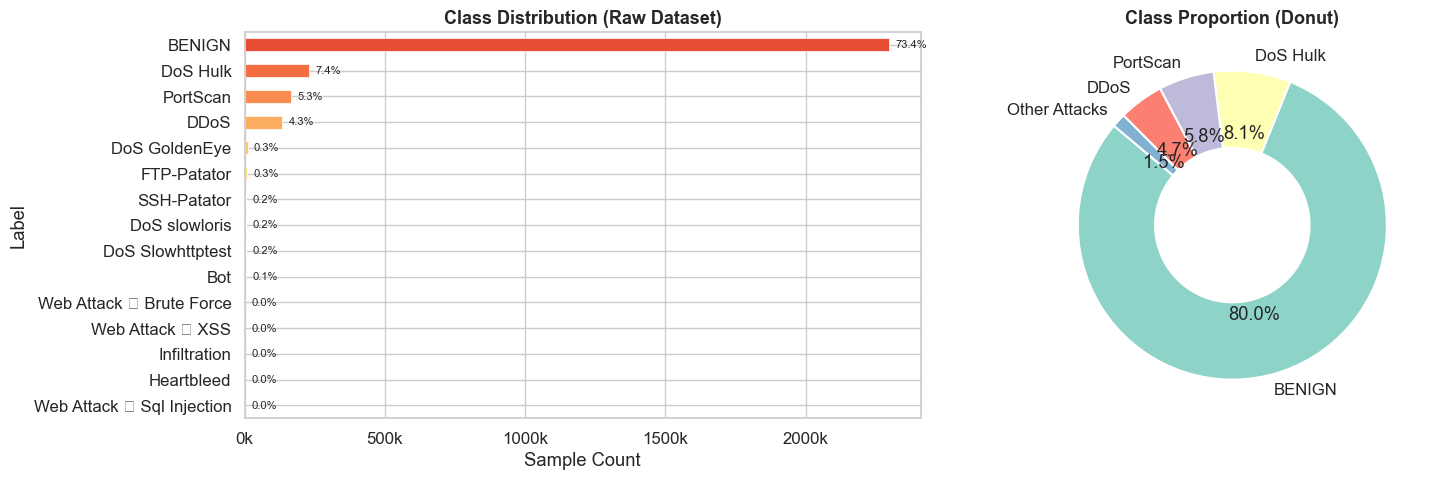

Saved fig01_class_distribution.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Class distribution bar chart ----
vc_sorted = raw_df['Label'].value_counts().sort_values(ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(vc_sorted)))
vc_sorted.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution (Raw Dataset)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sample Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for i, (val, patch) in enumerate(zip(vc_sorted, axes[0].patches)):
    axes[0].text(val + max(vc_sorted)*0.01, patch.get_y() + patch.get_height()/2,
                 f'{100*val/len(raw_df):.1f}%', va='center', fontsize=8)

# ---- Pie chart ----
vc_pie = raw_df['Label'].value_counts()
thresh = 0.02 * len(raw_df)
vc_major = vc_pie[vc_pie >= thresh]
other = vc_pie[vc_pie < thresh].sum()
if other > 0:
    vc_major['Other Attacks'] = other
wedge_props = dict(width=0.5, edgecolor='white', linewidth=1.5)
axes[1].pie(vc_major, labels=vc_major.index, autopct='%1.1f%%',
            startangle=140, wedgeprops=wedge_props,
            colors=plt.cm.Set3.colors[:len(vc_major)])
axes[1].set_title('Class Proportion (Donut)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig01_class_distribution.png')

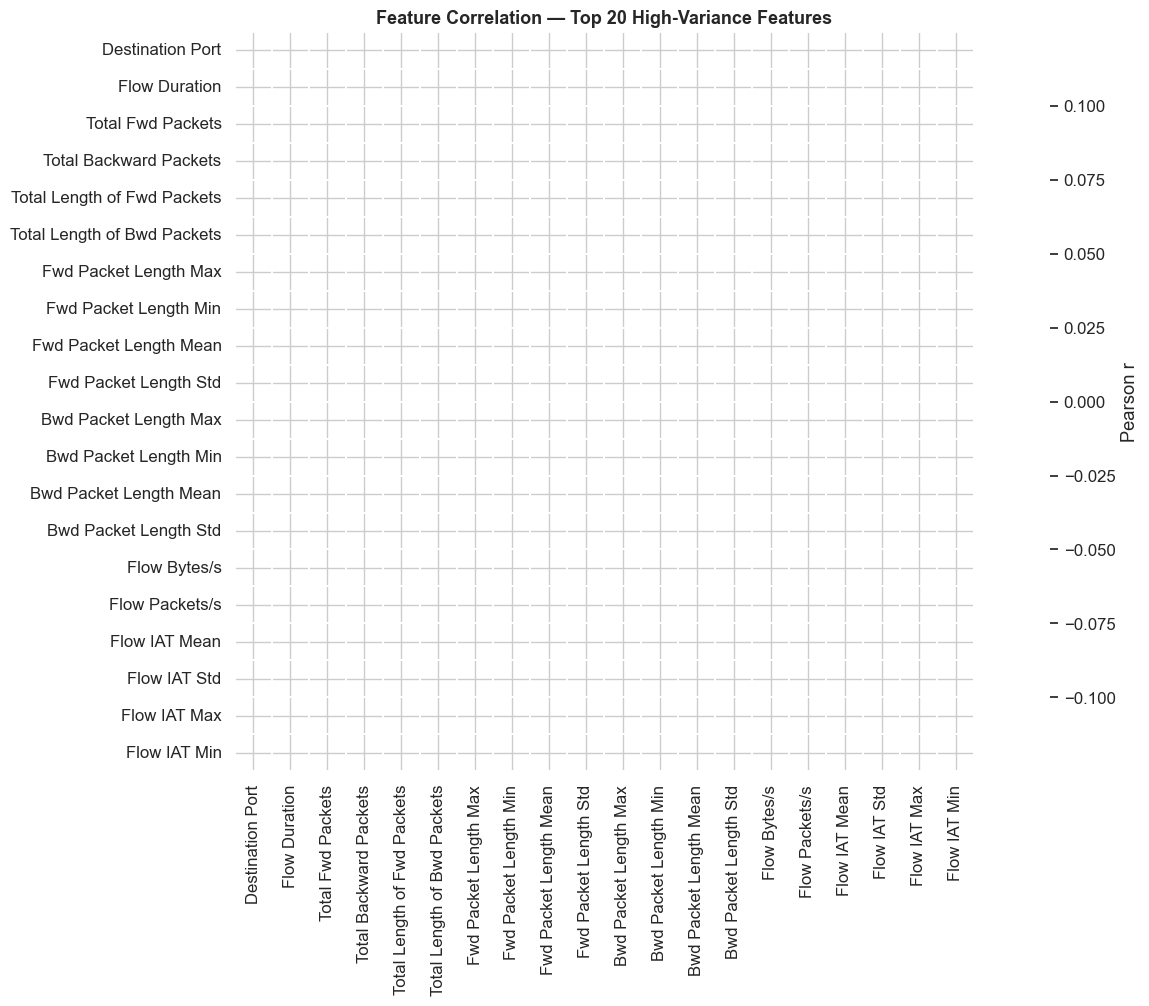

Saved fig02_correlation_heatmap.png


In [18]:
# ---- Feature correlation heatmap (top 20 features by variance) ----
num_cols = raw_df.select_dtypes(include=np.number).columns.tolist()
sample_df = raw_df[num_cols].replace([np.inf, -np.inf], np.nan).dropna()
top20 = sample_df.var().nlargest(20).index.tolist()

corr = sample_df[top20].sample(min(10000, len(sample_df)), random_state=SEED).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True,
            linewidths=0.3, ax=ax, annot=False,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Feature Correlation — Top 20 High-Variance Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig02_correlation_heatmap.png')

## 4. Cleaning & Feature Engineering

In [19]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Remove duplicates
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed : {before - len(df):,}')

    # Replace Inf / -Inf with NaN, then fill
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    nan_before = df[num_cols].isnull().sum().sum()
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    print(f'NaN/Inf values fixed: {nan_before:,}')

    # Clip extreme outliers (> 99.9th percentile) to reduce feature scale distortion
    for col in num_cols:
        upper = df[col].quantile(0.999)
        df[col] = df[col].clip(upper=upper)

    return df


clean_df = clean_dataset(raw_df)
print(f'\nClean shape: {clean_df.shape}')

Duplicates removed : 347,472
NaN/Inf values fixed: 123,518,464

Clean shape: (2780035, 124)


In [20]:
# ---- Label encoding ----
# Binary: BENIGN=0, any attack=1  (for simple classification)
# Multiclass: map attack families

clean_df['label_binary'] = (clean_df['Label'].str.strip() != 'BENIGN').astype(int)

attack_map_stripped = {k.strip(): v for k, v in ATTACK_TYPES.items()}
clean_df['label_multi'] = clean_df['Label'].fillna('BENIGN').str.strip().map(
    lambda x: next((v for k, v in attack_map_stripped.items() if k in x), 0)
)

print('Binary label counts:')
print(clean_df['label_binary'].value_counts())
print('\nMulticlass label counts:')
print(clean_df['label_multi'].value_counts())

Binary label counts:
label_binary
0    2096484
1     683551
Name: count, dtype: int64

Multiclass label counts:
label_multi
0    2356300
1     193748
2     128016
3      90819
4       9152
7       1953
6         36
8         11
Name: count, dtype: int64


## 5. Train / Stream Split

This is the critical split that models the research scenario:
- **ML models** receive 30% of data for batch training.
- **All models** are evaluated on the remaining 70%, fed **one sample at a time** to simulate live network traffic.
- Temporal ordering is **preserved** (shuffle=False) to maintain realistic concept drift.

In [21]:
from imblearn.under_sampling import RandomUnderSampler

FEATURE_COLS = [c for c in CIC_COLUMNS if c != 'Label' and c in clean_df.columns]
LABEL_COL    = 'label_binary'

X = clean_df[FEATURE_COLS].values.astype(np.float32)
y_bin = clean_df[LABEL_COL].values
y_multi = clean_df['label_multi'].values

# 1. Temporal split — 30% train, 70% streaming test
split_idx = int(len(X) * 0.30)
X_train, X_stream = X[:split_idx], X[split_idx:]
y_train, y_stream = y_bin[:split_idx], y_bin[split_idx:]
y_train_m, y_stream_m = y_multi[:split_idx], y_multi[split_idx:]

# 2. Standardize (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_stream_s = scaler.transform(X_stream)

# 3. Apply Undersampling to the Training Set only
# This ensures models learn what an attack looks like without being overwhelmed by benign data.
# sampling_strategy=0.5 means the minority class (attacks) will be 50% the size of the majority (benign).
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

# We resample X and the binary labels. 
# To keep the multiclass labels aligned, we'll use the indices of the resampled data.
X_train_res, y_train_res = rus.fit_resample(X_train_s, y_train)
resampled_indices = rus.sample_indices_
y_train_m_res = y_train_m[resampled_indices]

print(f'Original Training Attack Rate: {y_train.mean()*100:.2f}%')
print(f'Balanced Training set  : {X_train_res.shape}  |  New Attack rate: {y_train_res.mean()*100:.1f}%')
print(f'Streaming set (Untouched): {X_stream_s.shape}  |  Attack rate: {y_stream.mean()*100:.1f}%')

# 4. Persist updated artefacts
np.save(OUTPUT_DIR / 'X_train.npy', X_train_res)
np.save(OUTPUT_DIR / 'y_train.npy', y_train_res)
np.save(OUTPUT_DIR / 'y_train_multi.npy', y_train_m_res)
np.save(OUTPUT_DIR / 'X_stream.npy', X_stream_s)
np.save(OUTPUT_DIR / 'y_stream.npy', y_stream)
np.save(OUTPUT_DIR / 'y_stream_multi.npy', y_stream_m)
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')

print('Balanced artefacts saved to ./processed/')

Original Training Attack Rate: 26.48%
Balanced Training set  : (662505, 78)  |  New Attack rate: 33.3%
Streaming set (Untouched): (1946025, 78)  |  Attack rate: 23.8%
Balanced artefacts saved to ./processed/


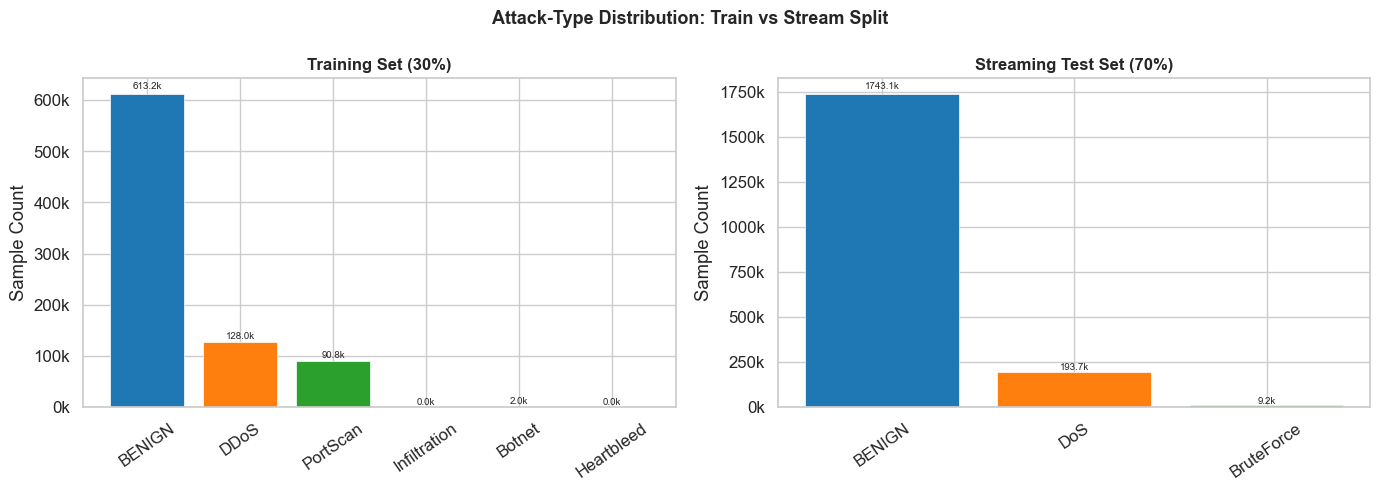

Saved fig03_train_stream_split.png


In [22]:
# ---- Visualize train vs stream attack distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y, title in zip(axes,
                        [y_train_m, y_stream_m],
                        ['Training Set (30%)', 'Streaming Test Set (70%)']):
    vc = Counter(y)
    labels = [LABEL_NAMES.get(k, str(k)) for k in sorted(vc.keys())]
    counts = [vc[k] for k in sorted(vc.keys())]
    bars = ax.bar(labels, counts, color=plt.cm.tab10.colors[:len(labels)],
                  edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Sample Count')
    ax.tick_params(axis='x', rotation=35)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h*1.01, f'{h/1e3:.1f}k',
                ha='center', va='bottom', fontsize=7)

plt.suptitle('Attack-Type Distribution: Train vs Stream Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig03_train_stream_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig03_train_stream_split.png')

## 6. Summary

| Artefact | Path | Description |
|---|---|---|
| X_train.npy | processed/ | 30% scaled training features |
| y_train.npy | processed/ | Binary labels for training set |
| y_train_multi.npy | processed/ | Multi-class labels for training set |
| X_stream.npy | processed/ | 70% scaled streaming features |
| y_stream.npy | processed/ | Binary labels for streaming set |
| y_stream_multi.npy | processed/ | Multi-class labels for streaming set |
| scaler.pkl | processed/ | Fitted StandardScaler |

**→ Proceed to Notebook 2: ML Baselines**